In [1]:
print("Hello World!")

Hello World!


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
courses = pd.read_csv("courses.csv")
assessments = pd.read_csv("assessments.csv")
vle = pd.read_csv("vle.csv")
studentInfo = pd.read_csv("studentInfo.csv")
studentRegistration = pd.read_csv("studentRegistration.csv")
studentAssessment = pd.read_csv("studentAssessment.csv")
studentVle = pd.read_csv("studentVle.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("courses:", courses.shape)
print("assessments:", assessments.shape)
print("vle:", vle.shape)
print("studentInfo:", studentInfo.shape)
print("studentRegistration:", studentRegistration.shape)
print("studentAssessment:", studentAssessment.shape)
print("studentVle:", studentVle.shape)

courses: (22, 3)
assessments: (206, 6)
vle: (6364, 6)
studentInfo: (32593, 12)
studentRegistration: (32593, 5)
studentAssessment: (173912, 5)
studentVle: (10655280, 6)


In [5]:
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [6]:
studentAssessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [7]:
studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [8]:
studentInfo.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [9]:
studentAssessment.isnull().sum()

id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

In [10]:
studentVle.isnull().sum()

code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

In [11]:
studentInfo["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [12]:
studentInfo["target"] = studentInfo["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

studentInfo[["final_result", "target"]].head()

,final_result,target
0,Pass,1
1,Pass,1
2,Withdrawn,0
3,Pass,1
4,Pass,1


In [13]:
studentInfo["target"].value_counts()

target
0    17208
1    15385
Name: count, dtype: int64

In [14]:
studentInfo["target"].value_counts(normalize=True) * 100

target
0    52.796613
1    47.203387
Name: proportion, dtype: float64

In [15]:
studentInfo.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'target'],
      dtype='object')

In [16]:
studentAssessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [17]:
studentAssessment['id_student'].nunique()

23369

In [18]:
studentAssessment[studentAssessment['id_student'] == 11391]

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
501,1753,11391,53,0,85.0
842,1754,11391,115,0,80.0
1032,1755,11391,164,0,85.0
1457,1756,11391,212,0,82.0


In [19]:
assessment_features = studentAssessment.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    assessments_completed=('score', 'count')
).reset_index()

In [20]:
assessment_features.head()

,id_student,avg_score,assessments_completed
0,6516,61.800000,5
1,8462,87.000000,7
2,11391,82.000000,5
3,23629,82.500000,4
4,23698,74.444444,9


In [21]:
ml_data = studentInfo.merge(
    assessment_features,
    on='id_student',
    how='left'
)

In [22]:
ml_data.shape

(32593, 15)

In [23]:
ml_data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,avg_score,assessments_completed
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,5.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,5.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,5.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,5.0


In [24]:
studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [25]:
vle_features = studentVle.groupby('id_student').agg(
    total_clicks=('sum_click', 'sum')
).reset_index()

In [26]:
vle_features.head()

,id_student,total_clicks
0,6516,2791
1,8462,656
2,11391,934
3,23629,161
4,23698,910


In [27]:
ml_data = ml_data.merge(
    vle_features,
    on='id_student',
    how='left'
)

In [28]:
ml_data.shape

(32593, 16)

In [29]:
ml_data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,avg_score,assessments_completed,total_clicks
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,5.0,934.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,5.0,1435.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0,NaN,NaN,281.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,5.0,2158.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,5.0,1034.0


In [30]:
ml_data.isnull().sum()

code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
target                      0
avg_score                5866
assessments_completed    5847
total_clicks             2852
dtype: int64

In [31]:
ml_data['avg_score'] = ml_data['avg_score'].fillna(0)
ml_data['assessments_completed'] = ml_data['assessments_completed'].fillna(0)
ml_data['total_clicks'] = ml_data['total_clicks'].fillna(0)

ml_data['imd_band'] = ml_data['imd_band'].fillna('Unknown')

In [32]:
ml_data.isnull().sum()

code_module              0
code_presentation        0
id_student               0
gender                   0
region                   0
highest_education        0
imd_band                 0
age_band                 0
num_of_prev_attempts     0
studied_credits          0
disability               0
final_result             0
target                   0
avg_score                0
assessments_completed    0
total_clicks             0
dtype: int64

In [33]:
ml_data.select_dtypes(include='object').columns

Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'disability',
       'final_result'],
      dtype='object')

In [34]:
y = ml_data['target']
X = ml_data.drop(columns=['target', 'final_result', 'id_student'])

In [35]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [36]:
X_encoded.shape

(32593, 44)

In [37]:
X_encoded.head()

,num_of_prev_attempts,studied_credits,avg_score,assessments_completed,total_clicks,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,disability_Y
0,0,240,82.0,5.0,934.0,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
1,0,60,66.4,5.0,1435.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,0,60,0.0,0.0,281.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True
3,0,60,76.0,5.0,2158.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
4,0,60,54.4,5.0,1034.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=5000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [40]:
y_pred = model_lr.predict(X_test)

In [41]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8573400828347906
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      3442
           1       0.83      0.88      0.85      3077

    accuracy                           0.86      6519
   macro avg       0.86      0.86      0.86      6519
weighted avg       0.86      0.86      0.86      6519



In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
y_pred_rf = model_rf.predict(X_test)

In [45]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8929283632458966
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      3442
           1       0.86      0.92      0.89      3077

    accuracy                           0.89      6519
   macro avg       0.89      0.89      0.89      6519
weighted avg       0.90      0.89      0.89      6519



In [46]:
from xgboost import XGBClassifier

In [47]:
model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

Demographics
gender
region
highest_education
imd_band
age_band
disability
Academic History
num_of_prev_attempts
studied_credits
Performance
avg_score
assessments_completed
Engagement
total_clicks
Context
code_module
code_presentation
Target
success/failure

In [49]:
studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [50]:
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [52]:
ml_data = ml_data.merge(
    studentRegistration[
        ['id_student', 'date_registration']
    ],
    on='id_student',
    how='left'
)

In [53]:
ml_data = ml_data.merge(
    courses,
    on=['code_module', 'code_presentation'],
    how='left'
)

In [54]:
ml_data.shape

(59155, 19)

In [55]:
ml_data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,avg_score,assessments_completed,total_clicks,date_registration_x,date_registration_y,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,5.0,934.0,-159.0,-159.0,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,5.0,1435.0,-53.0,-53.0,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0,0.0,0.0,281.0,-92.0,-92.0,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,5.0,2158.0,-52.0,-52.0,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,5.0,1034.0,-176.0,-176.0,268


problem

In [56]:
ml_data[['date_registration_x', 'date_registration_y']].head()

,date_registration_x,date_registration_y
0,-159.0,-159.0
1,-53.0,-53.0
2,-92.0,-92.0
3,-52.0,-52.0
4,-176.0,-176.0


In [57]:
ml_data = ml_data.drop(columns=['date_registration_y'])

ml_data = ml_data.rename(
    columns={'date_registration_x': 'date_registration'}
)

In [58]:
ml_data.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'target', 'avg_score',
       'assessments_completed', 'total_clicks', 'date_registration',
       'module_presentation_length'],
      dtype='object')

got final dataset version 1

In [59]:
ml_data['gender'].value_counts()

gender
M    37765
F    21390
Name: count, dtype: int64

In [60]:
ml_data['disability'].value_counts()

disability
N    52691
Y     6464
Name: count, dtype: int64

In [61]:
ml_data.groupby('gender')['target'].mean() * 100

gender
F    42.613371
M    40.849993
Name: target, dtype: float64

In [65]:
ml_data.groupby('disability')['target'].mean() * 100

# This immediately gives you a research question:

# Students with declared disabilities appear to have substantially lower success rates than students without declared disabilities.

# This does not prove discrimination.

# But it does mean disability should definitely be one of the sensitive attributes in your fairness evaluation.

disability
N    42.604999
Y    32.379332
Name: target, dtype: float64

something messed up in the rows

In [63]:
ml_data.shape

(59155, 18)

In [64]:
ml_data['id_student'].nunique()

28785

In [ ]:
# duplicate rows

In [66]:
studentRegistration.shape

(32593, 5)

In [67]:
studentRegistration[
    ['id_student', 'code_module', 'code_presentation']
].duplicated().sum()

np.int64(0)

In [68]:
ml_data[
    ['id_student', 'code_module', 'code_presentation']
].duplicated().sum()

np.int64(26562)

In [69]:
ml_data[['id_student', 'code_module', 'code_presentation']].shape

(59155, 3)

In [70]:
ml_data[['id_student', 'code_module', 'code_presentation']].drop_duplicates().shape

(32593, 3)

In [71]:
ml_data = ml_data.drop_duplicates(
    subset=['id_student', 'code_module', 'code_presentation']
)

In [72]:
ml_data.shape

(32593, 18)

In [73]:
ml_data['id_student'].nunique()

28785

In [74]:
ml_data[
    ['id_student', 'code_module', 'code_presentation']
].duplicated().sum()

np.int64(0)

In [75]:
ml_data.to_csv("oulad_final_dataset.csv", index=False)

In [76]:
ml_data['target'].value_counts()

target
0    17208
1    15385
Name: count, dtype: int64

In [77]:
ml_data['target'].value_counts(normalize=True) * 100

target
0    52.796613
1    47.203387
Name: proportion, dtype: float64

EDA

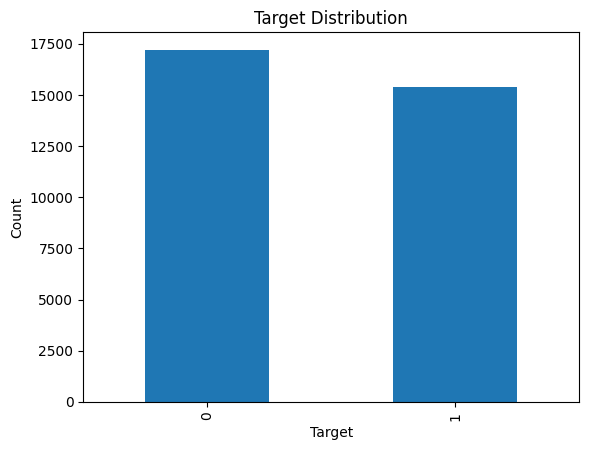

In [78]:
import matplotlib.pyplot as plt

ml_data['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

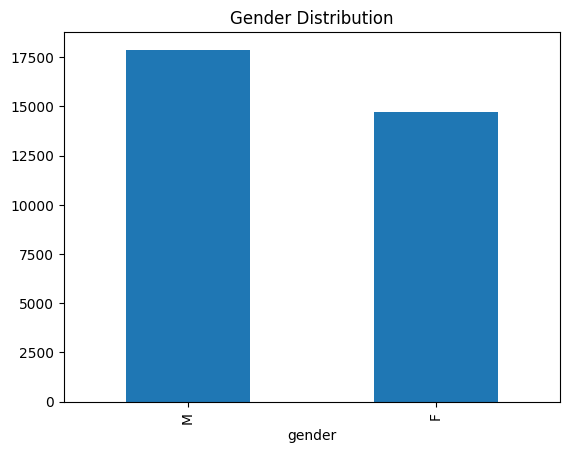

In [79]:
ml_data['gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

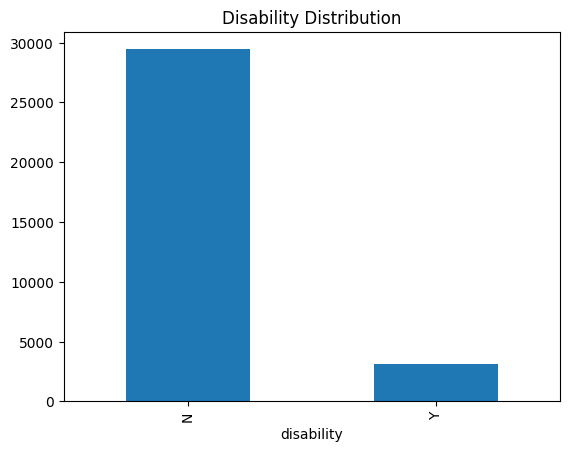

In [80]:
ml_data['disability'].value_counts().plot(kind='bar')
plt.title('Disability Distribution')
plt.show()

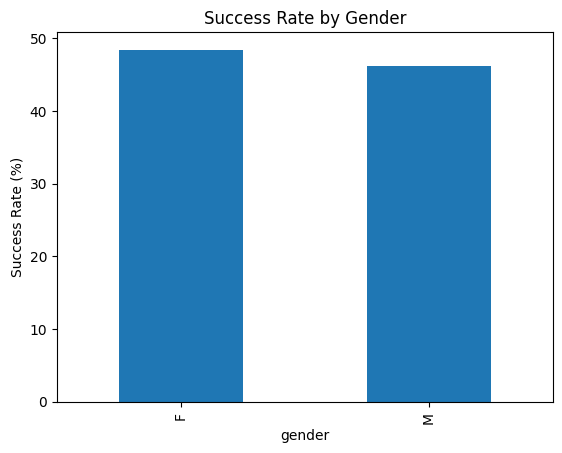

In [81]:
(ml_data.groupby('gender')['target'].mean()*100).plot(kind='bar')
plt.title('Success Rate by Gender')
plt.ylabel('Success Rate (%)')
plt.show()

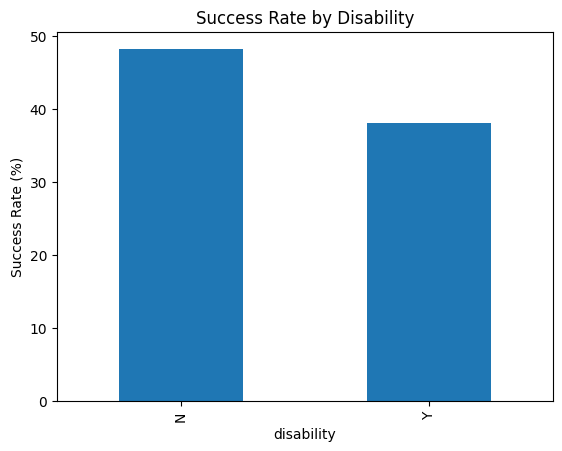

In [82]:
(ml_data.groupby('disability')['target'].mean()*100).plot(kind='bar')
plt.title('Success Rate by Disability')
plt.ylabel('Success Rate (%)')
plt.show()

new modeling

In [83]:
X = ml_data.drop(columns=['id_student', 'final_result', 'target'])
y = ml_data['target']

print(X.shape)
print(y.shape)

(32593, 15)
(32593,)


In [84]:
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)

(32593, 46)


In [85]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

In [86]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [87]:
log_reg = LogisticRegression(max_iter=2000)

accuracy = cross_val_score(log_reg, X_encoded, y, cv=skf, scoring='accuracy')
f1 = cross_val_score(log_reg, X_encoded, y, cv=skf, scoring='f1')

print("Logistic Regression Results")
print("Accuracy:", accuracy.mean())
print("F1:", f1.mean())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1222, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lin

SOLVING THE NAN ISSUE

In [88]:
X_encoded.isnull().sum().sort_values(ascending=False).head(10)

date_registration             48
num_of_prev_attempts           0
studied_credits                0
avg_score                      0
assessments_completed          0
total_clicks                   0
module_presentation_length     0
code_module_BBB                0
code_module_CCC                0
code_module_DDD                0
dtype: int64

In [89]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [90]:
log_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

In [91]:
accuracy = cross_val_score(log_reg, X_encoded, y, cv=skf, scoring='accuracy')
f1 = cross_val_score(log_reg, X_encoded, y, cv=skf, scoring='f1')

print("Logistic Regression (Fixed)")
print("Accuracy:", accuracy.mean())
print("F1:", f1.mean())

Logistic Regression (Fixed)
Accuracy: 0.8559505975428777
F1: 0.8532531909623987


In [92]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

accuracy = cross_val_score(rf, X_encoded, y, cv=skf, scoring='accuracy')
f1 = cross_val_score(rf, X_encoded, y, cv=skf, scoring='f1')

print("Random Forest")
print("Accuracy:", accuracy.mean())
print("F1:", f1.mean())

Random Forest
Accuracy: 0.8938729103085319
F1: 0.8920075135456935


In [94]:
X_encoded = X_encoded.copy()

X_encoded.columns = (
    X_encoded.columns
    .str.replace(r"[^\w]", "_", regex=True)
)

In [95]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

accuracy = cross_val_score(xgb, X_encoded, y, cv=skf, scoring='accuracy')
f1 = cross_val_score(xgb, X_encoded, y, cv=skf, scoring='f1')

print("XGBoost")
print("Accuracy:", accuracy.mean())
print("F1:", f1.mean())

XGBoost
Accuracy: 0.8978921010790983
F1: 0.895864333635841


In [96]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

accuracy = cross_val_score(xgb, X_encoded, y, cv=skf, scoring='accuracy')
f1 = cross_val_score(xgb, X_encoded, y, cv=skf, scoring='f1')

print("XGBoost")
print("Accuracy:", accuracy.mean())
print("F1:", f1.mean())

XGBoost
Accuracy: 0.8978921010790983
F1: 0.895864333635841
